# Initial Time Series Analysis: UK Agricultural Input Costs

Covers the period **2015–2026**, aligned with the UK fruit & vegetable wholesale price series. The goal is to characterise the time series properties of fuel prices, agricultural price indices, and road freight costs — the primary input-cost drivers in UK food production.

### Sections
1. Data Loading & Series Selection  
2. Visual Inspection  
3. STL Decomposition (Trend / Seasonal / Residual)  
4. Stationarity Tests (ADF & KPSS)  
5. ACF & PACF  
6. Periodogram — Dominant Frequencies  
7. Rolling Statistics (Volatility)  
8. Cross-Correlation Between Input Cost Series  
9. Granger Causality  
10. Summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# statsmodels
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, grangercausalitytests, ccf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# scipy
from scipy import signal
from scipy.stats import pearsonr

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['figure.dpi'] = 100

DATA = 'data/'

## 1. Data Loading & Series Selection

In [2]:
# Agricultural Price Index (API)
api = pd.read_csv(DATA + 'API_20260129.csv')
api['date'] = pd.to_datetime(api['date'])
api_pivot = api.pivot_table(index='date', columns='category', values='index')

# Fuel prices
fuel = pd.concat([
    pd.read_csv(DATA + 'weekly_road_fuel_prices_2003_to_2017.csv'),
    pd.read_csv(DATA + 'weekly_road_fuel_prices_2018_to_now.csv')
], ignore_index=True)
fuel.columns = ['date', 'petrol_price', 'diesel_price',
                'petrol_duty', 'diesel_duty', 'petrol_vat', 'diesel_vat']
fuel['date'] = pd.to_datetime(fuel['date'], dayfirst=True)
fuel = fuel.sort_values('date').drop_duplicates('date').reset_index(drop=True)

# SPPI (road freight)
sppi_raw = pd.read_csv(DATA + 'series-210226.csv', header=None)
data_start = next(i for i in range(len(sppi_raw))
                  if str(sppi_raw.iloc[i, 0]).strip()[:4].isdigit())
sppi = (sppi_raw.iloc[data_start:, [0, 1]]
        .rename(columns={0: 'period', 1: 'value'}))
sppi['value'] = pd.to_numeric(sppi['value'], errors='coerce')
sppi = sppi.dropna(subset=['value']).reset_index(drop=True)

def parse_period(p):
    p = str(p).strip()
    if 'Q' in p:
        yr, q = int(p.split()[0]), int(p.split()[1][1:])
        return pd.Timestamp(year=yr, month=(q - 1) * 3 + 1, day=1)
    return pd.Timestamp(year=int(p), month=1, day=1)

sppi['date'] = sppi['period'].apply(parse_period)
sppi = sppi.sort_values('date').drop_duplicates('date').reset_index(drop=True)

print(f"API:  {api_pivot.shape}   |  {api_pivot.index.min().date()} → {api_pivot.index.max().date()}")
print(f"Fuel: {fuel.shape}        |  {fuel['date'].min().date()} → {fuel['date'].max().date()}")
print(f"SPPI: {sppi.shape}        |  {sppi['date'].min().date()} → {sppi['date'].max().date()}")
print(f"\nAPI categories: {sorted(api_pivot.columns.tolist())}")

API:  (143, 106)   |  2014-01-01 → 2025-11-01
Fuel: (1185, 7)        |  2003-06-09 → 2026-02-16
SPPI: (119, 3)        |  1996-01-01 → 2025-07-01

API categories: ['all_agricultural_inputs', 'all_agricultural_outputs', 'all_goods_and_services_currently_consumed_in_agriculture', 'all_poultry', 'animal_feedingstuffs', 'animal_products', 'animals_and_animal_products', 'animals_for_slaughter_export', 'barley', 'barley_feeding', 'barley_malting', 'beans_green', 'buildings', 'cabbages', 'calves', 'carrots', 'cattle_and_calves', 'cattle_clean', 'cauliflowers', 'cereal_and_milling_by_products', 'cereals', 'chickens', 'compound_feedingstuffs', 'compound_feedingstuffs_for_cattle_and_calves', 'compound_feedingstuffs_for_pigs', 'compound_feedingstuffs_for_poultry', 'compound_feedingstuffs_for_sheep', 'compound_fertilisers', 'cooking_apples', 'cows_and_bulls', 'crop_products', 'dessert_apples', 'dessert_pears', 'eggs', 'electricity', 'energy_and_lubricants', 'ewes_and_rams', 'farm_machinery_and_inst

In [3]:
# Build aligned weekly panel
# API (monthly) and SPPI (quarterly) are forward-filled after upsampling to
# weekly frequency.  Fuel is natively weekly.

API_COLS = ['energy_and_lubricants', 'fertilisers_and_soil_improvers',
            'seeds_input', 'plant_protection_products']
API_COLS = [c for c in API_COLS if c in api_pivot.columns]

api_w  = api_pivot[API_COLS].resample('W').ffill()
fuel_w = fuel.set_index('date')[['diesel_price', 'petrol_price']].resample('W').mean()
sppi_w = (sppi.set_index('date')[['value']]
              .rename(columns={'value': 'freight_sppi'})
              .resample('W').ffill())

panel = api_w.join(fuel_w, how='outer').join(sppi_w, how='outer')

# Align with the fruit & vegetable price series window
START = pd.Timestamp('2015-01-09')
END   = pd.Timestamp('2026-02-16')
panel = panel.loc[START:END]

target_cols = list(panel.columns)
print(f"Panel shape: {panel.shape}")
print(f"Date range:  {panel.index.min().date()} → {panel.index.max().date()}")
print(f"\nNull counts:\n{panel.isnull().sum()}")

Panel shape: (580, 7)
Date range:  2015-01-11 → 2026-02-15

Null counts:
energy_and_lubricants             15
fertilisers_and_soil_improvers    15
seeds_input                       15
plant_protection_products         15
diesel_price                       0
petrol_price                       0
freight_sppi                      32
dtype: int64


In [4]:
# Series metadata & availability
SERIES_META = {
    'energy_and_lubricants': {
        'label': 'Energy & Lubricants', 'source': 'API (DEFRA)',
        'freq': 'monthly', 'unit': 'index (2015=100)',
    },
    'fertilisers_and_soil_improvers': {
        'label': 'Fertilisers & Improvers', 'source': 'API (DEFRA)',
        'freq': 'monthly', 'unit': 'index (2015=100)',
    },
    'seeds_input': {
        'label': 'Seeds Input', 'source': 'API (DEFRA)',
        'freq': 'monthly', 'unit': 'index (2015=100)',
    },
    'plant_protection_products': {
        'label': 'Plant Protection Products', 'source': 'API (DEFRA)',
        'freq': 'monthly', 'unit': 'index (2015=100)',
    },
    'diesel_price': {
        'label': 'Diesel Price', 'source': 'BEIS',
        'freq': 'weekly', 'unit': 'pence/litre',
    },
    'petrol_price': {
        'label': 'Petrol Price', 'source': 'BEIS',
        'freq': 'weekly', 'unit': 'pence/litre',
    },
    'freight_sppi': {
        'label': 'Road Freight SPPI', 'source': 'ONS',
        'freq': 'quarterly', 'unit': 'index',
    },
}

print(f"{'Label':<32} {'Source':<15} {'Freq':<12} {'Unit':<22} {'Start':<12} {'End':<12} {'N wks'}")
print('-' * 110)
for col in target_cols:
    s = panel[col].dropna()
    m = SERIES_META.get(col, {'label': col, 'source': '?', 'freq': '?', 'unit': '?'})
    print(f"{m['label']:<32} {m['source']:<15} {m['freq']:<12} {m['unit']:<22} "
          f"{s.index.min().date()} {s.index.max().date()} {len(s)}")

Label                            Source          Freq         Unit                   Start        End          N wks
--------------------------------------------------------------------------------------------------------------
Energy & Lubricants              API (DEFRA)     monthly      index (2015=100)       2015-01-11 2025-11-02 565
Fertilisers & Improvers          API (DEFRA)     monthly      index (2015=100)       2015-01-11 2025-11-02 565
Seeds Input                      API (DEFRA)     monthly      index (2015=100)       2015-01-11 2025-11-02 565
Plant Protection Products        API (DEFRA)     monthly      index (2015=100)       2015-01-11 2025-11-02 565
Diesel Price                     BEIS            weekly       pence/litre            2015-01-11 2026-02-15 580
Petrol Price                     BEIS            weekly       pence/litre            2015-01-11 2026-02-15 580
Road Freight SPPI                ONS             quarterly    index                  2015-01-11 2025-07-06

In [5]:
def series_label(col):
    """Short display label for a column name."""
    return SERIES_META.get(col, {}).get('label', col)

def series_unit(col):
    """Unit string for a column."""
    return SERIES_META.get(col, {}).get('unit', '')

print("Helpers defined: series_label(), series_unit()")
print(f"target_cols: {target_cols}")

Helpers defined: series_label(), series_unit()
target_cols: ['energy_and_lubricants', 'fertilisers_and_soil_improvers', 'seeds_input', 'plant_protection_products', 'diesel_price', 'petrol_price', 'freight_sppi']


## 2. Visual Inspection

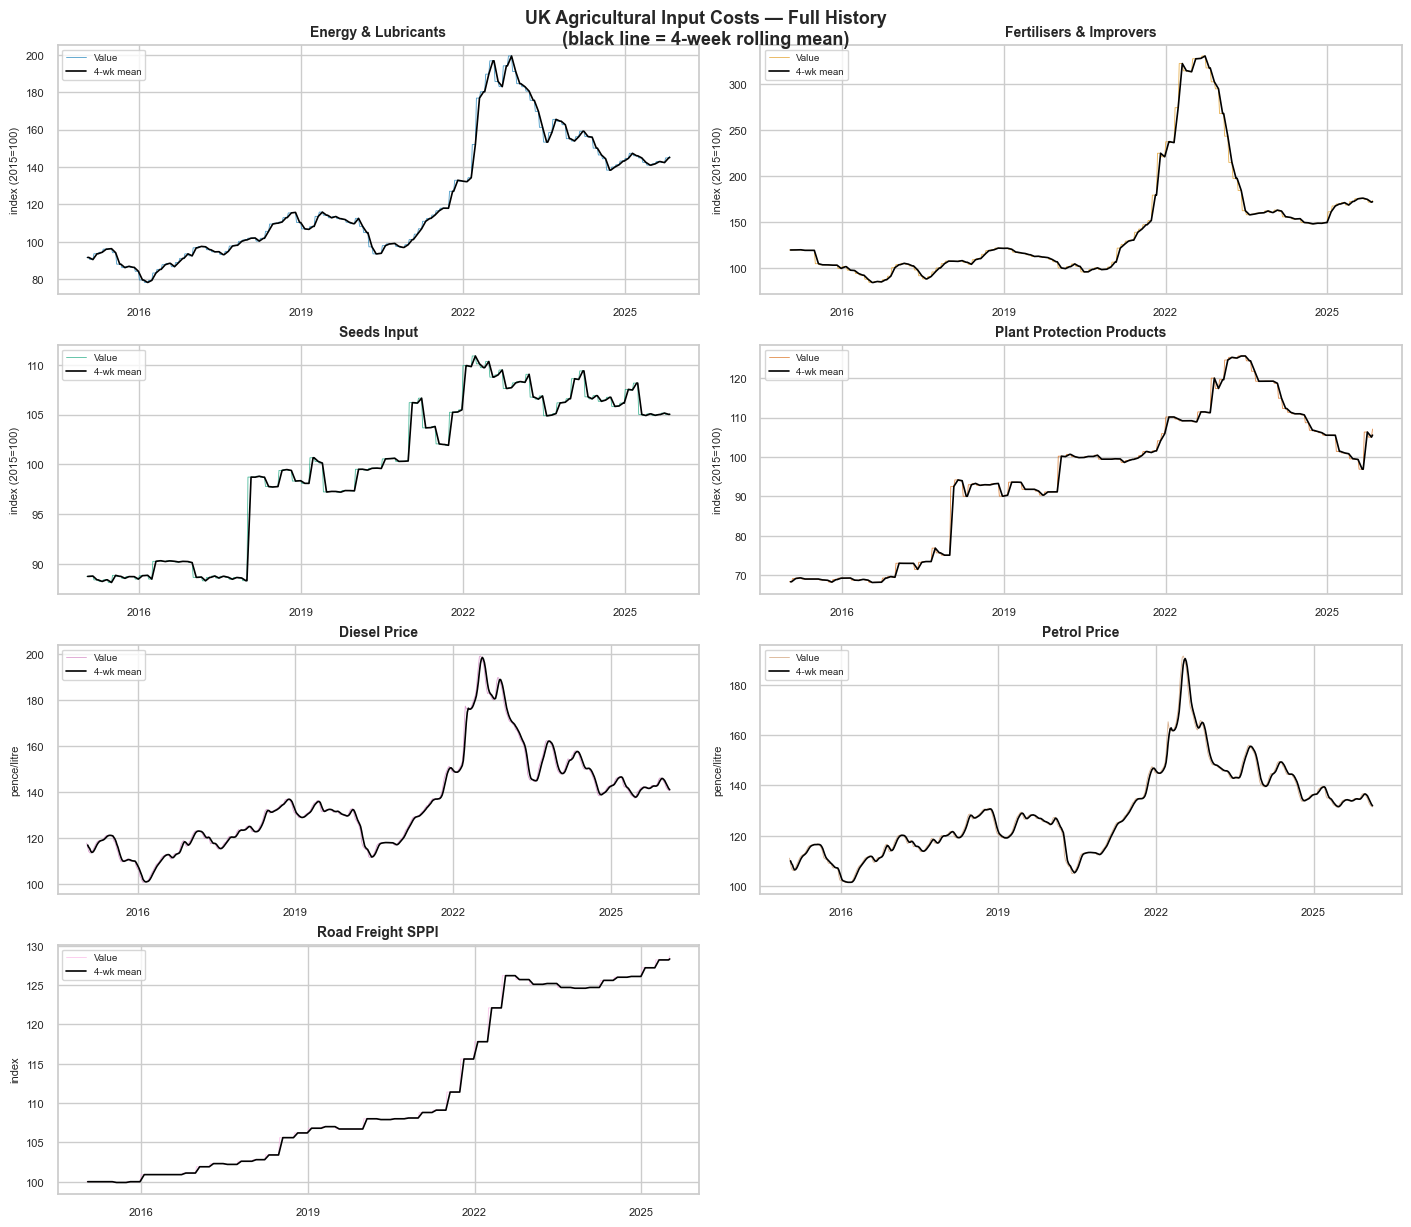

In [6]:
ncols = 2
nrows = (len(target_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 7, nrows * 3),
                         constrained_layout=True)
axes_flat = np.array(axes).flatten()

palette = sns.color_palette('colorblind', len(target_cols))
for ax, col, color in zip(axes_flat, target_cols, palette):
    s = panel[col].dropna()
    roll = s.rolling(4, min_periods=2).mean()
    ax.plot(s.index, s.values, linewidth=0.6, color=color, alpha=0.7, label='Value')
    ax.plot(roll.index, roll.values, color='black', linewidth=1.2, label='4-wk mean')
    ax.set_title(series_label(col), fontsize=10, fontweight='bold')
    ax.set_ylabel(series_unit(col), fontsize=8)
    ax.tick_params(labelsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(3))
    ax.legend(fontsize=7, loc='upper left')

for ax in axes_flat[len(target_cols):]:
    ax.set_visible(False)

fig.suptitle('UK Agricultural Input Costs — Full History\n'
             '(black line = 4-week rolling mean)',
             fontsize=13, fontweight='bold', y=1.01)
plt.show()

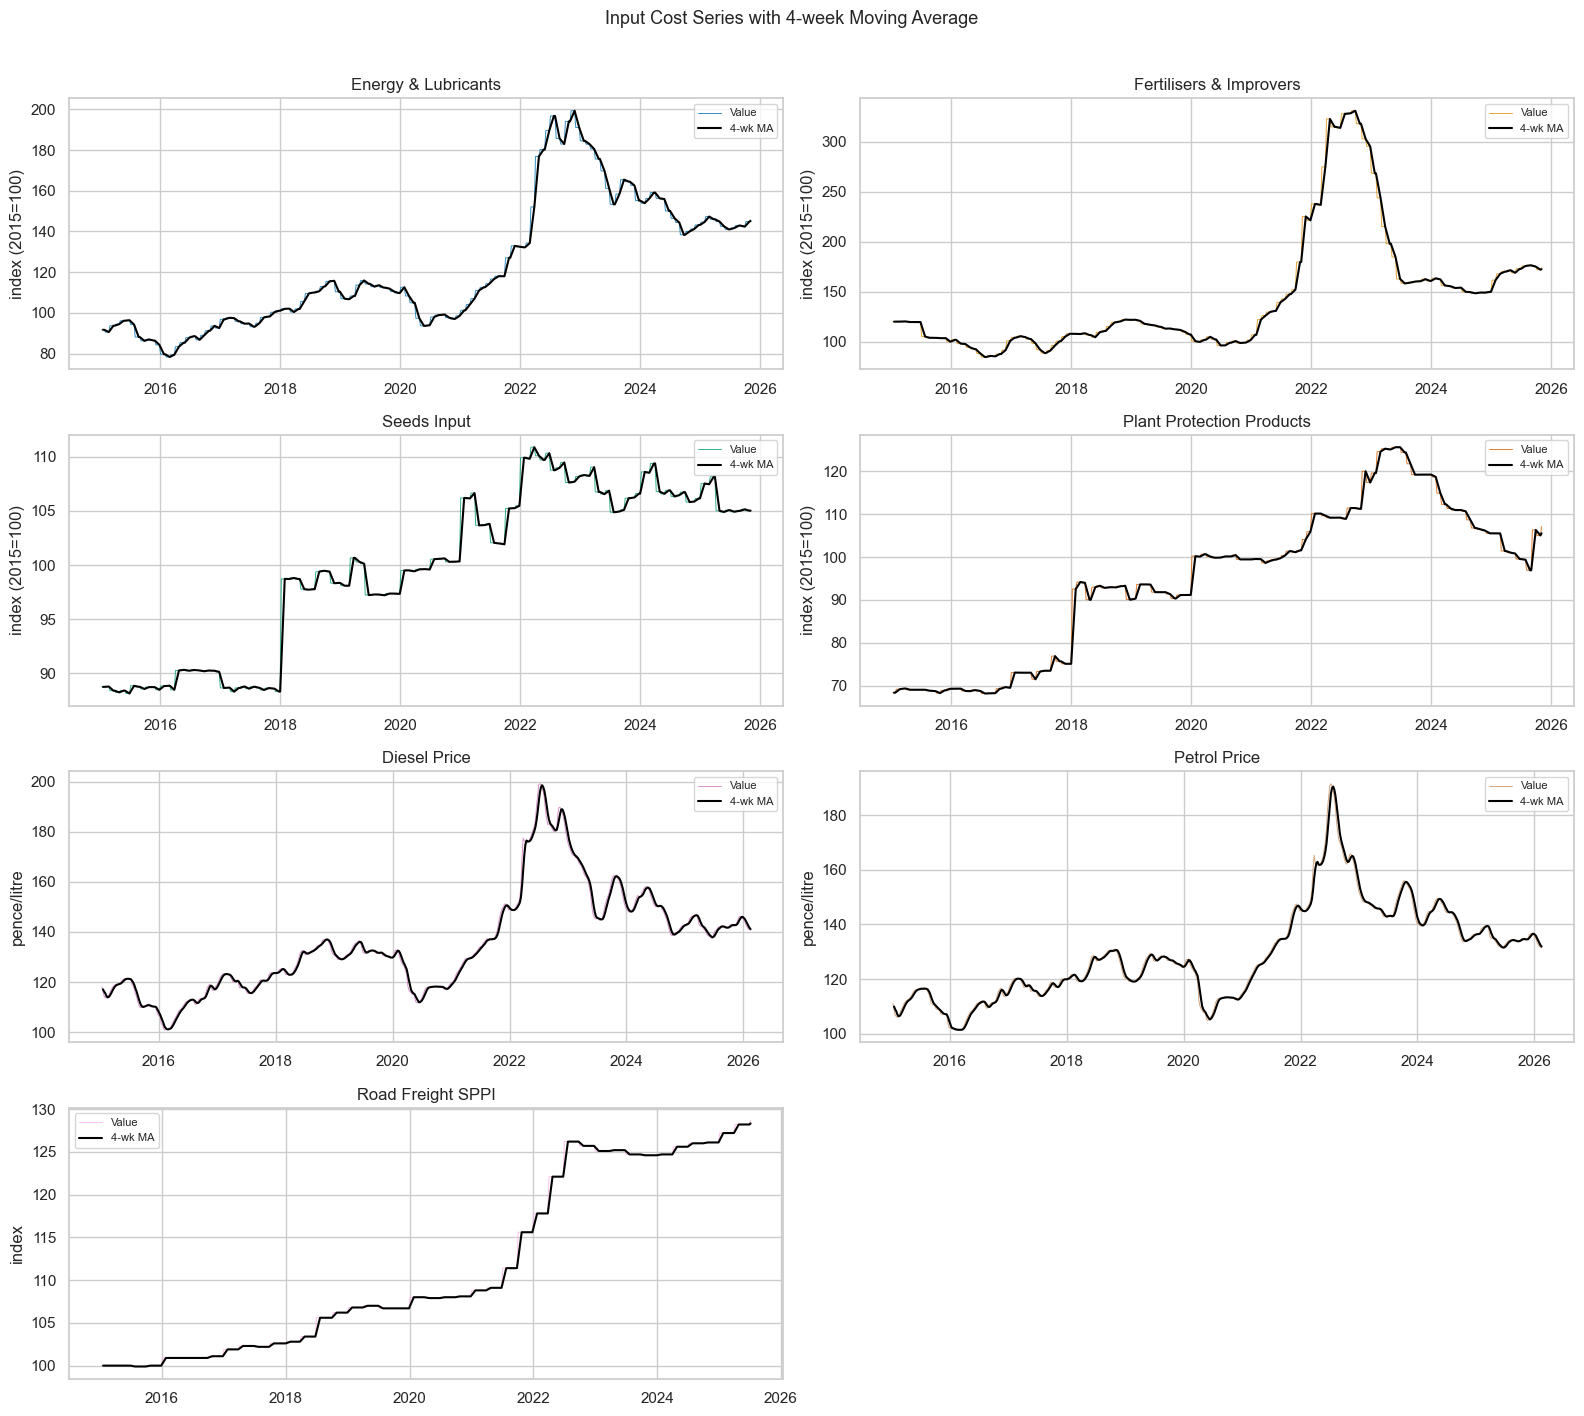

In [7]:
ncols = 2
nrows = (len(target_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes_flat = np.array(axes).flatten()

colors = sns.color_palette('colorblind', len(target_cols))
for ax, col, color in zip(axes_flat, target_cols, colors):
    s = panel[col].dropna()
    ax.plot(s.index, s.values, color=color, linewidth=0.7, alpha=0.8, label='Value')
    roll = s.rolling(4, min_periods=2).mean()
    ax.plot(roll.index, roll.values, color='black', linewidth=1.5, label='4-wk MA')
    ax.set_title(series_label(col))
    ax.set_ylabel(series_unit(col))
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes_flat[len(target_cols):]:
    ax.set_visible(False)

fig.suptitle('Input Cost Series with 4-week Moving Average', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

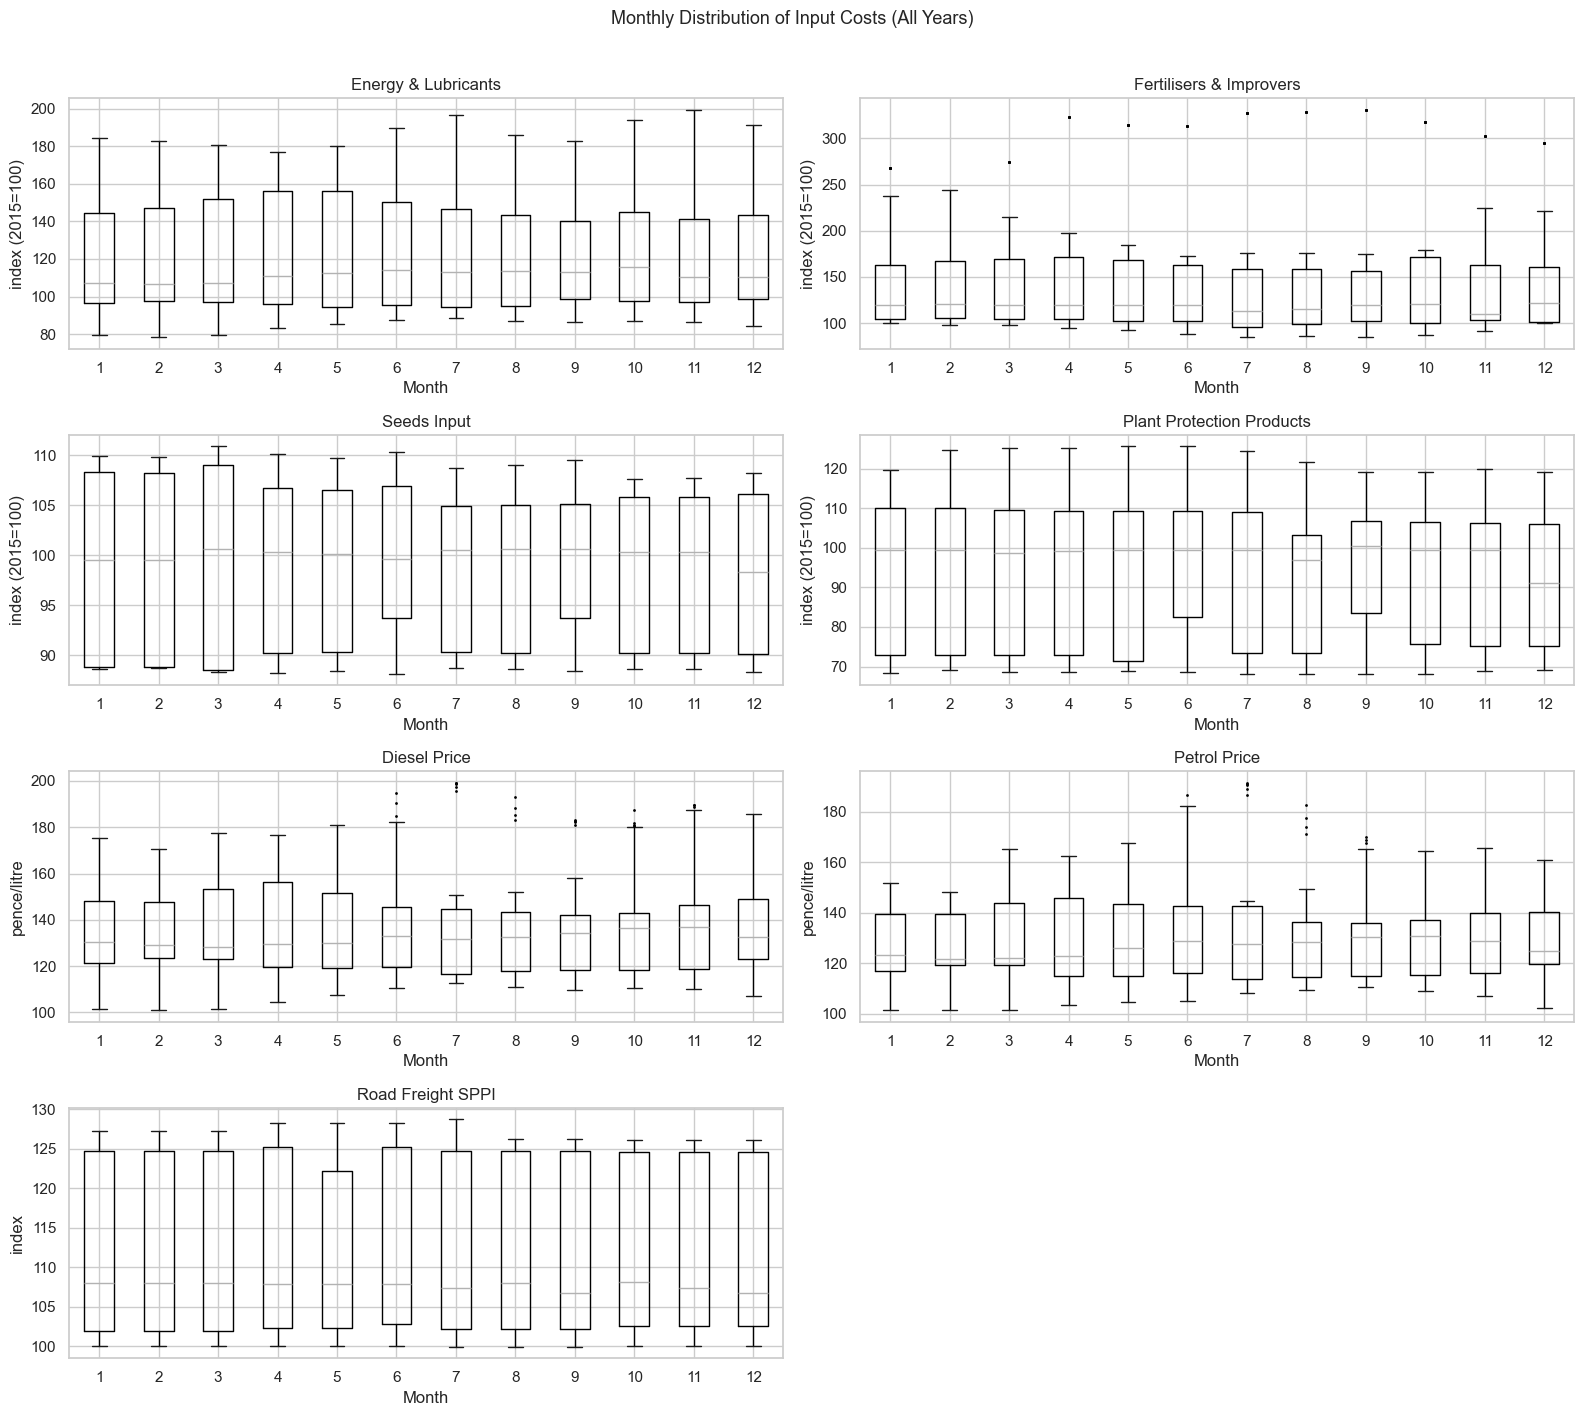

In [8]:
# Seasonal box plots — value by calendar month (all years pooled)
ncols = 2
nrows = (len(target_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes_flat = np.array(axes).flatten()

for ax, col in zip(axes_flat, target_cols):
    s = panel[col].dropna()
    df_tmp = pd.DataFrame({'month': s.index.month, 'value': s.values})
    df_tmp.boxplot(column='value', by='month', ax=ax,
                   flierprops=dict(marker='.', markersize=2))
    ax.set_title(series_label(col))
    ax.set_xlabel('Month')
    ax.set_ylabel(series_unit(col))

for ax in axes_flat[len(target_cols):]:
    ax.set_visible(False)

fig.suptitle('Monthly Distribution of Input Costs (All Years)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. STL Decomposition

STL (Seasonal-Trend decomposition using LOESS) handles non-constant seasonal amplitude and is robust to outliers. We use a period of **52 weeks** (annual cycle).

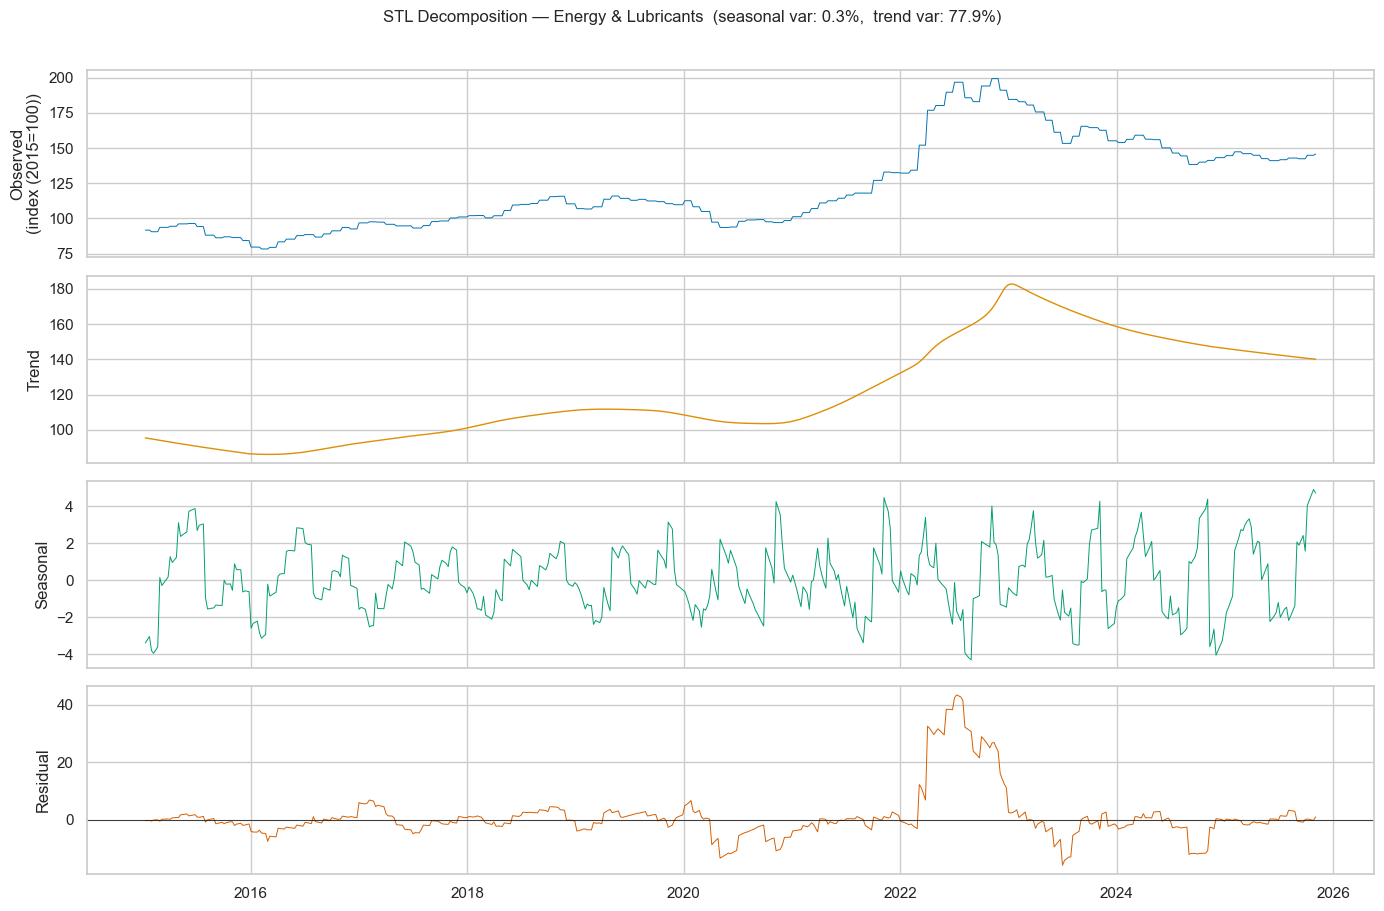

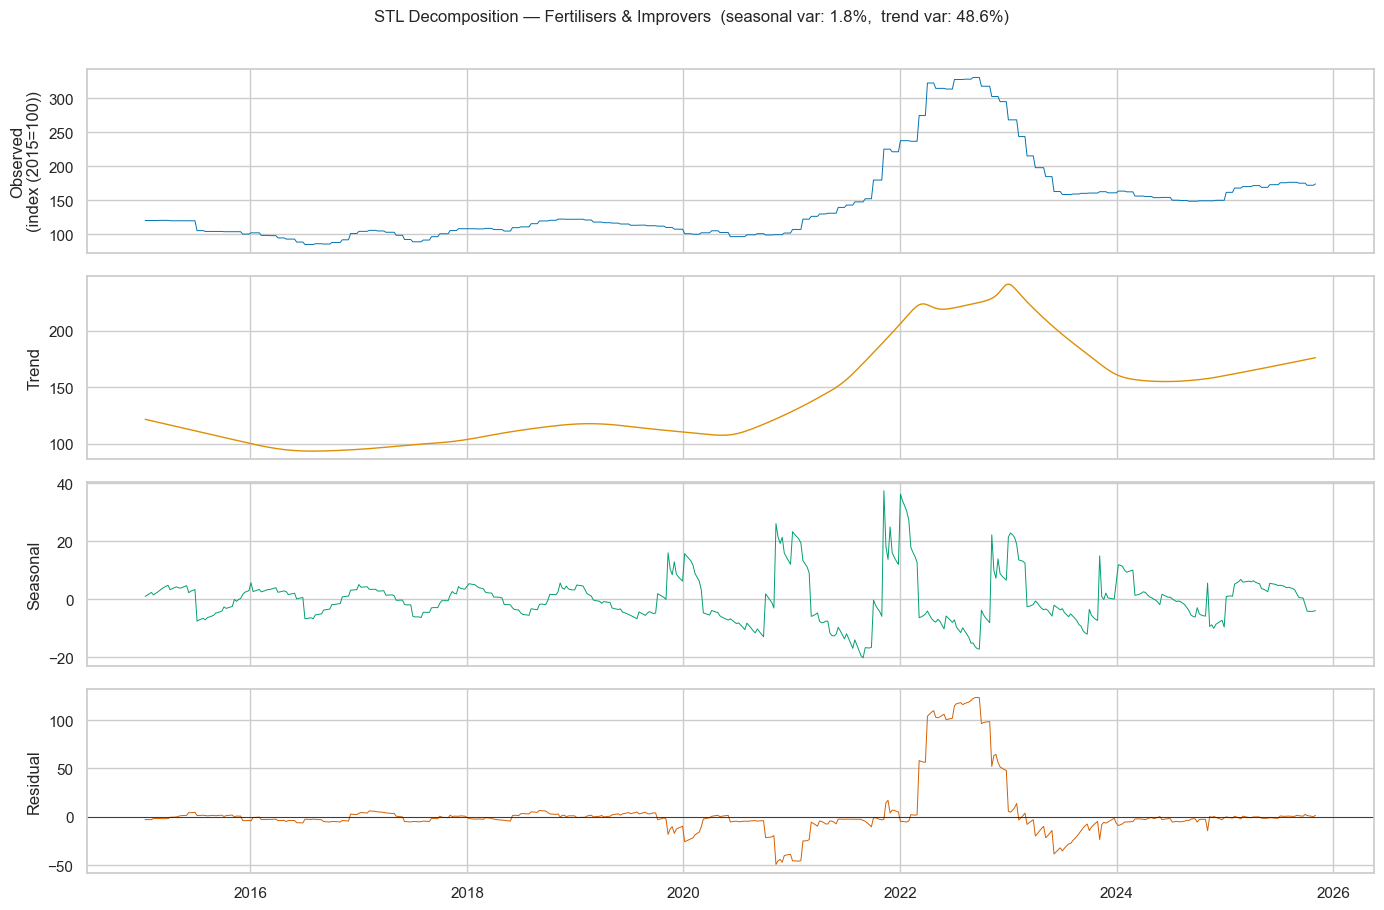

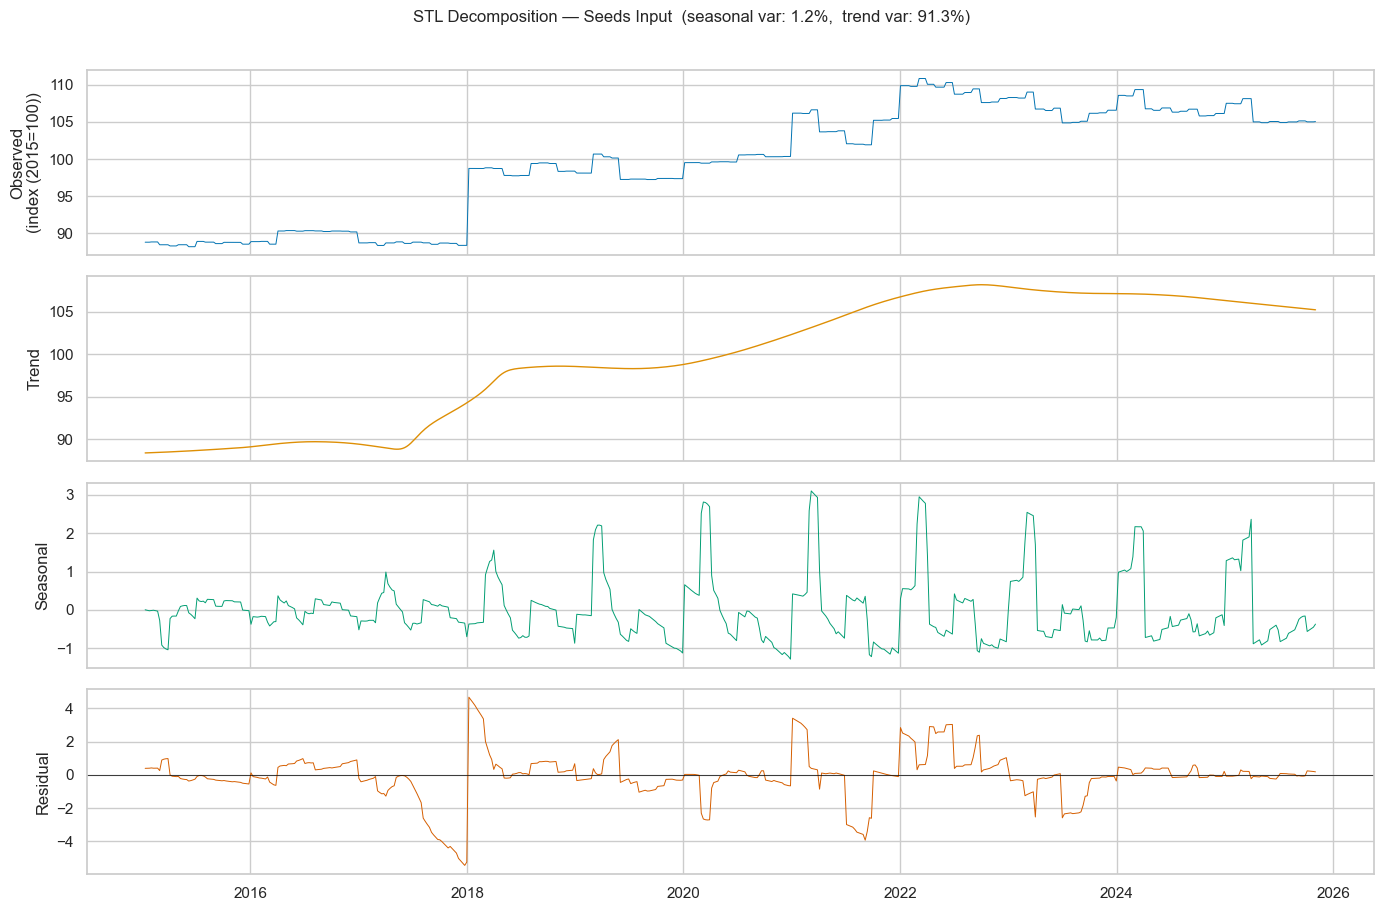

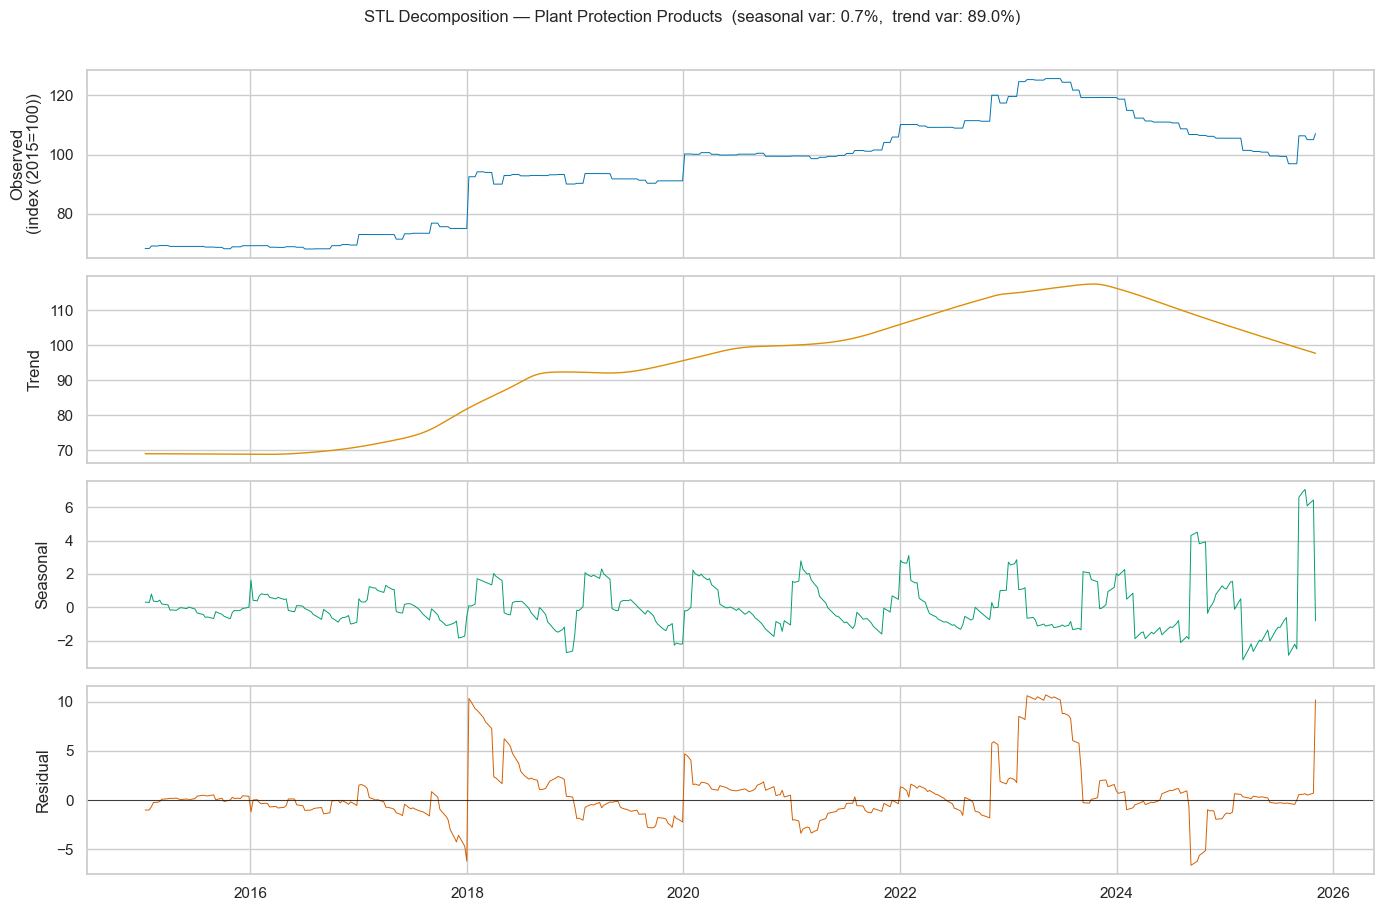

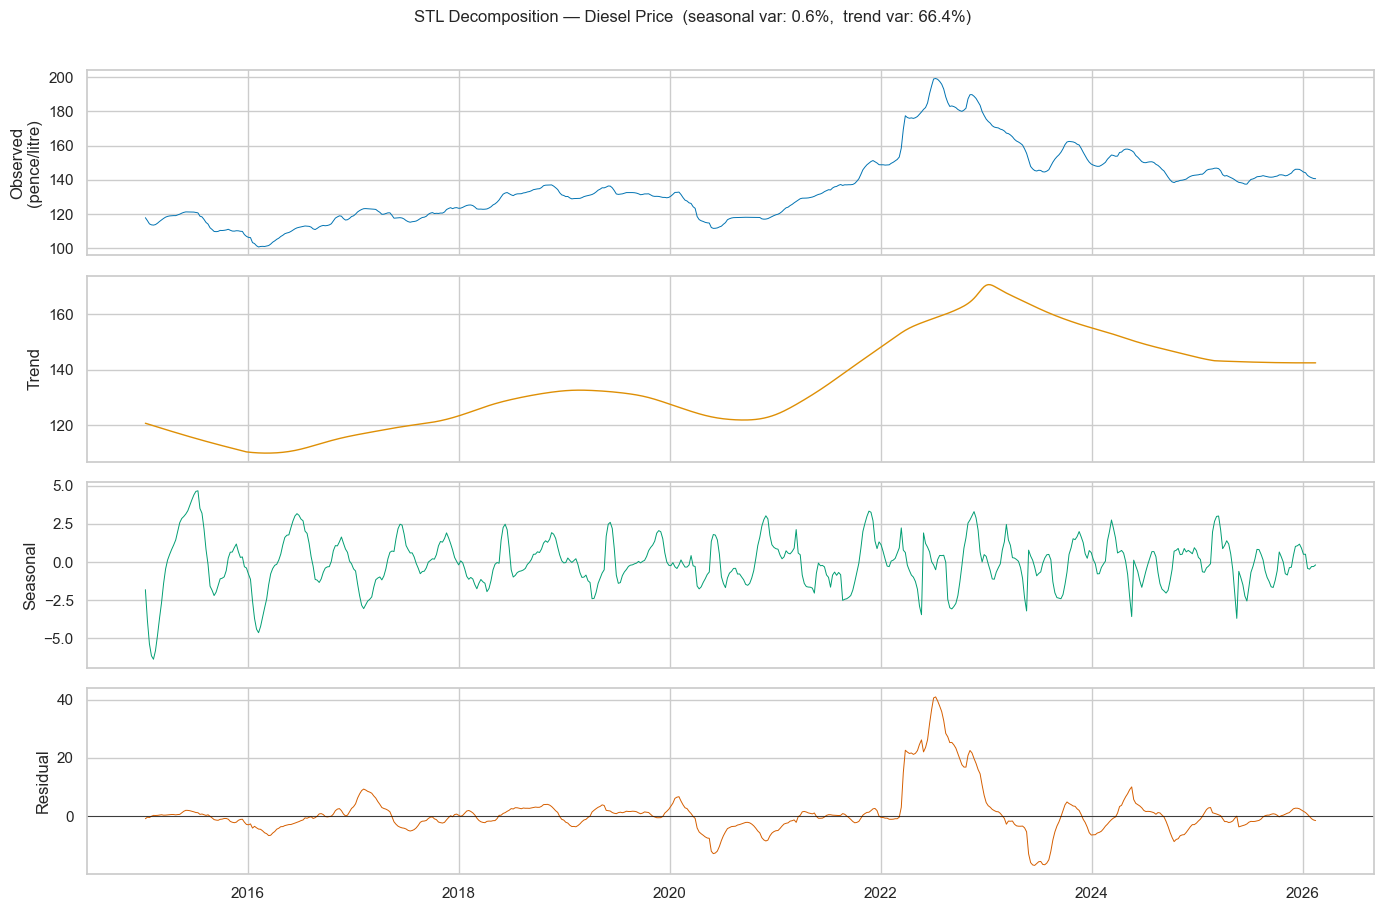

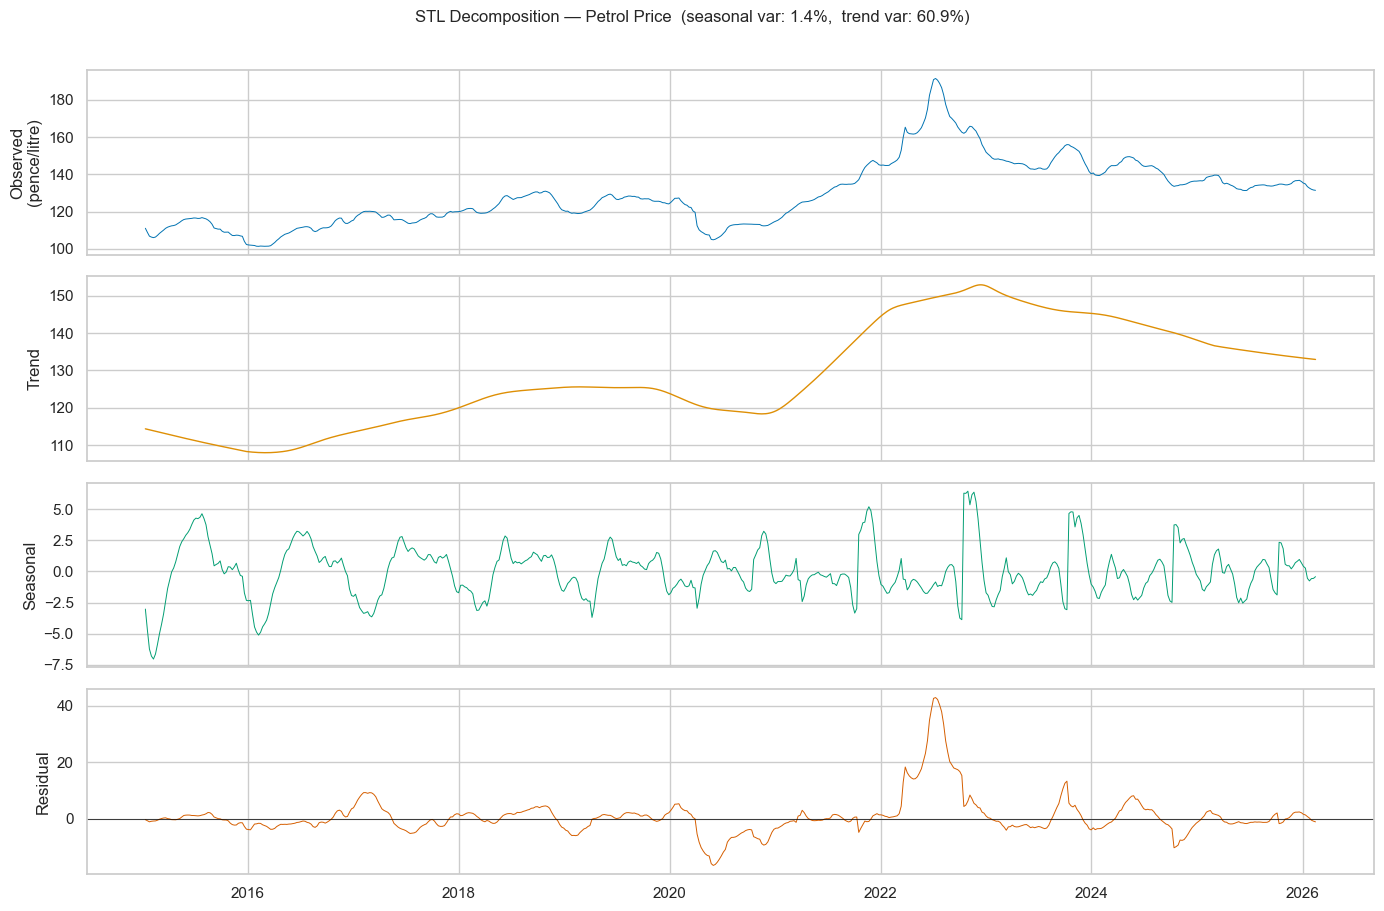

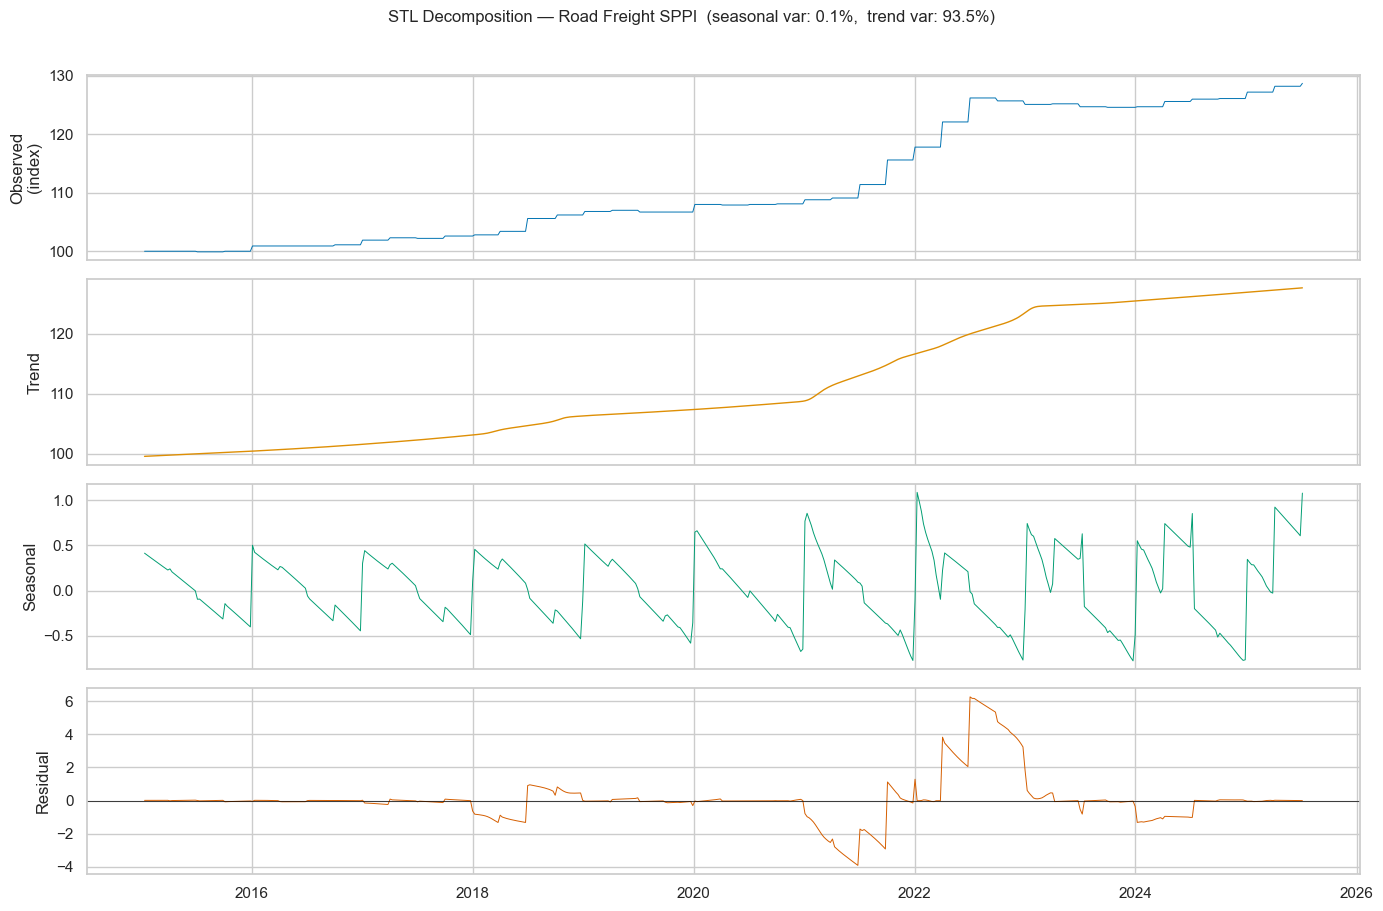

In [9]:
stl_results = {}

for name in target_cols:
    s = panel[name].dropna()
    # Need at least 2 full periods; skip if too sparse
    if len(s) < 2 * 52:
        print(f"  {name}: skipped (too few observations)")
        continue
    # Reindex to uniform weekly frequency, fill remaining gaps
    s = s.asfreq('W').interpolate(method='time')
    stl = STL(s, period=52, robust=True)
    res = stl.fit()
    stl_results[name] = res

    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(s.index, s.values, linewidth=0.7)
    axes[0].set_ylabel(f'Observed\n({series_unit(name)})')
    axes[1].plot(res.trend.index, res.trend.values, color='C1', linewidth=1)
    axes[1].set_ylabel('Trend')
    axes[2].plot(res.seasonal.index, res.seasonal.values, color='C2', linewidth=0.7)
    axes[2].set_ylabel('Seasonal')
    axes[3].plot(res.resid.index, res.resid.values, color='C3', linewidth=0.7)
    axes[3].axhline(0, color='black', linewidth=0.5)
    axes[3].set_ylabel('Residual')
    for ax in axes:
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    var_seas  = np.var(res.seasonal) / np.var(s) * 100
    var_trend = np.var(res.trend.dropna()) / np.var(s) * 100
    fig.suptitle(f'STL Decomposition — {series_label(name)}  '
                 f'(seasonal var: {var_seas:.1f}%,  trend var: {var_trend:.1f}%)',
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

## 4. Stationarity Tests

- **ADF (Augmented Dickey-Fuller)**: H₀ = unit root (non-stationary). Reject → stationary.  
- **KPSS**: H₀ = stationary. Reject → non-stationary.  

We test the raw series and the first-differenced series.

In [10]:
def run_stationarity(s, name, differenced=False):
    s = s.dropna()
    if differenced:
        s = s.diff().dropna()
    if len(s) < 20:
        label = f"{name} (Δ1)" if differenced else name
        return {'Series': label, 'ADF stat': 'n/a', 'ADF p': 'n/a',
                'ADF 5% crit': 'n/a', 'KPSS stat': 'n/a', 'KPSS p': 'n/a',
                'Conclusion': 'insufficient data'}
    # ADF
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(s, autolag='AIC')
    # KPSS
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
    except Exception:
        kpss_stat, kpss_p = np.nan, np.nan
    label = f"{name} (Δ1)" if differenced else name
    if adf_p < 0.05 and kpss_p > 0.05:
        conclusion = "STATIONARY"
    elif adf_p >= 0.05 and kpss_p <= 0.05:
        conclusion = "NON-STATIONARY"
    else:
        conclusion = "ambiguous"
    return {
        'Series': label,
        'ADF stat': round(adf_stat, 3),
        'ADF p': round(adf_p, 4),
        'ADF 5% crit': round(adf_crit['5%'], 3),
        'KPSS stat': round(kpss_stat, 3) if not np.isnan(kpss_stat) else 'n/a',
        'KPSS p': round(kpss_p, 4) if not np.isnan(kpss_p) else 'n/a',
        'Conclusion': conclusion
    }

rows = []
for name in target_cols:
    s = panel[name].dropna().asfreq('W').interpolate('time')
    rows.append(run_stationarity(s, series_label(name), differenced=False))
    rows.append(run_stationarity(s, series_label(name), differenced=True))

stat_df = pd.DataFrame(rows)
stat_df

C:\Users\zhang\AppData\Local\Temp\ipykernel_59340\3560759246.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
C:\Users\zhang\AppData\Local\Temp\ipykernel_59340\3560759246.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
C:\Users\zhang\AppData\Local\Temp\ipykernel_59340\3560759246.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
C:\Users\zhang\AppData\Local\Temp\ipykernel_59340\3560759246.py:14: Inter

,Series,ADF stat,ADF p,ADF 5% crit,KPSS stat,KPSS p,Conclusion
0,Energy & Lubricants,-1.209,0.6696,-2.867,2.431,0.01,NON-STATIONARY
1,Energy & Lubricants (Δ1),-4.806,0.0001,-2.867,0.109,0.10,STATIONARY
2,Fertilisers & Improvers,-2.462,0.1251,-2.867,1.456,0.01,NON-STATIONARY
3,Fertilisers & Improvers (Δ1),-3.109,0.0259,-2.867,0.125,0.10,STATIONARY
4,Seeds Input,-1.456,0.5553,-2.867,3.042,0.01,NON-STATIONARY
5,Seeds Input (Δ1),-23.728,0.0000,-2.867,0.083,0.10,STATIONARY
6,Plant Protection Products,-1.379,0.5923,-2.867,2.898,0.01,NON-STATIONARY
7,Plant Protection Products (Δ1),-23.702,0.0000,-2.867,0.168,0.10,STATIONARY
8,Diesel Price,-1.794,0.3835,-2.867,2.023,0.01,NON-STATIONARY
9,Diesel Price (Δ1),-10.126,0.0000,-2.867,0.093,0.10,STATIONARY


## 5. ACF & PACF

ACF and PACF of the **seasonally-adjusted residuals** (from STL) help identify AR and MA orders for the ARIMA model. We also show the raw differenced series for comparison.

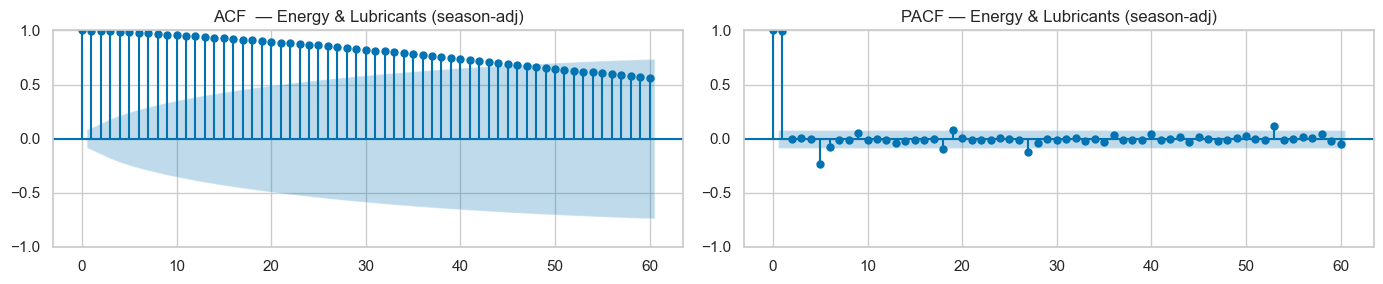

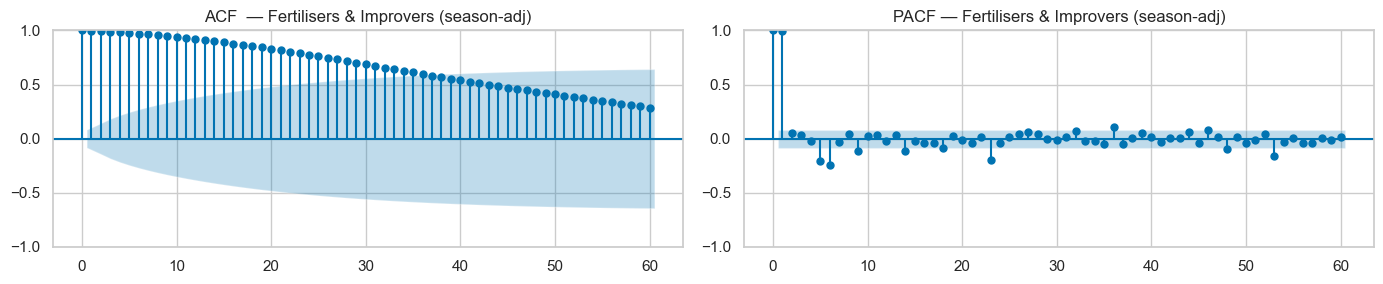

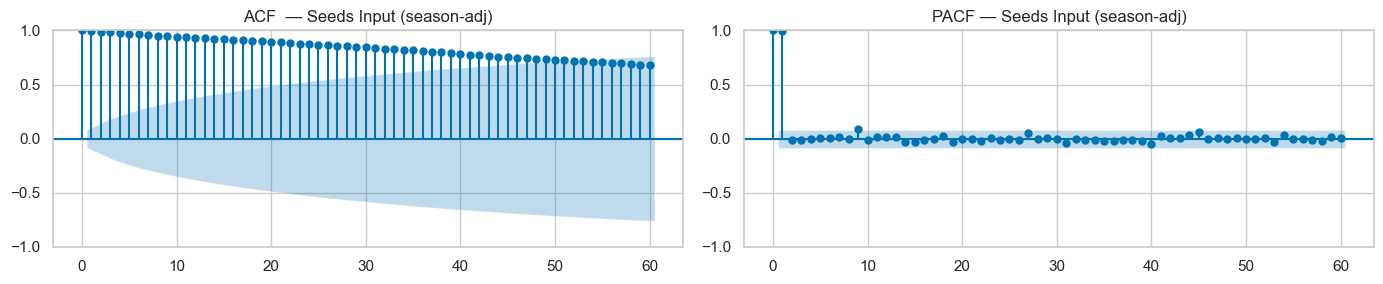

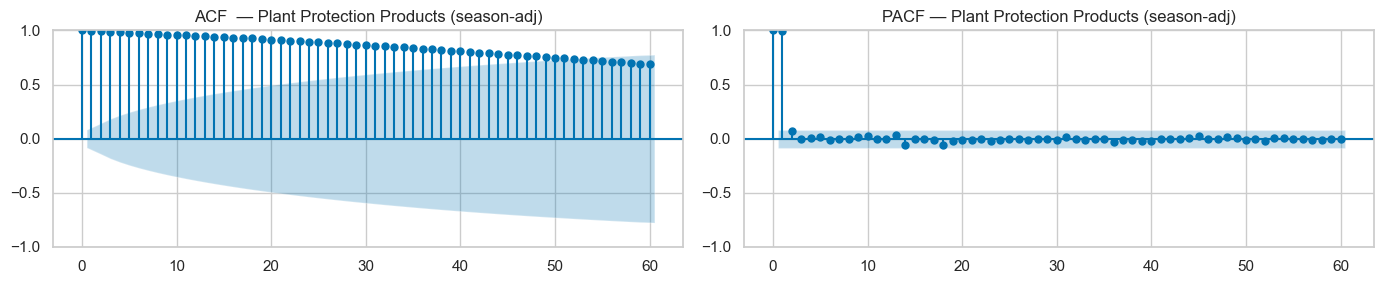

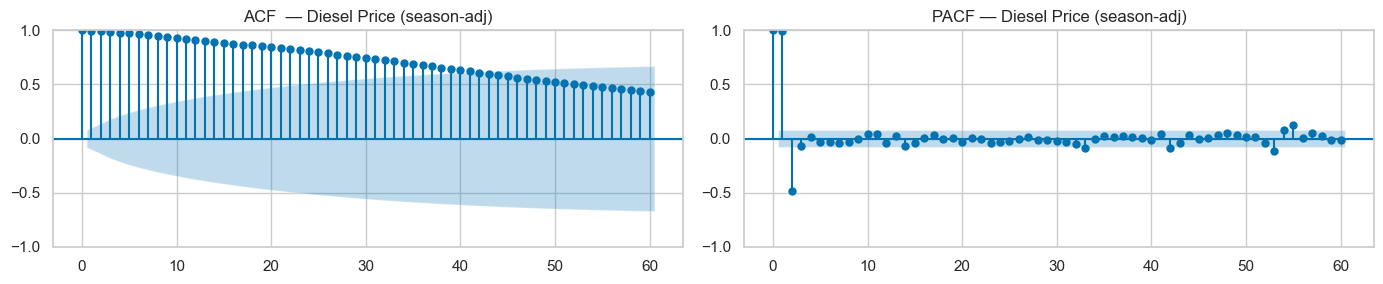

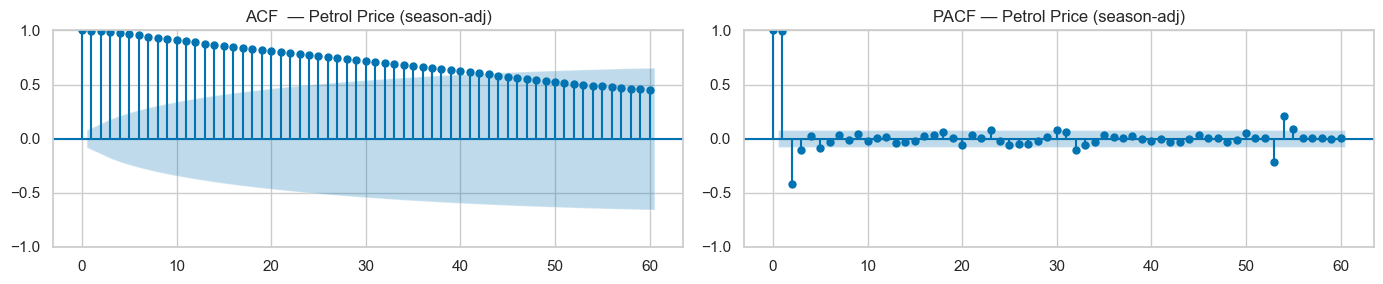

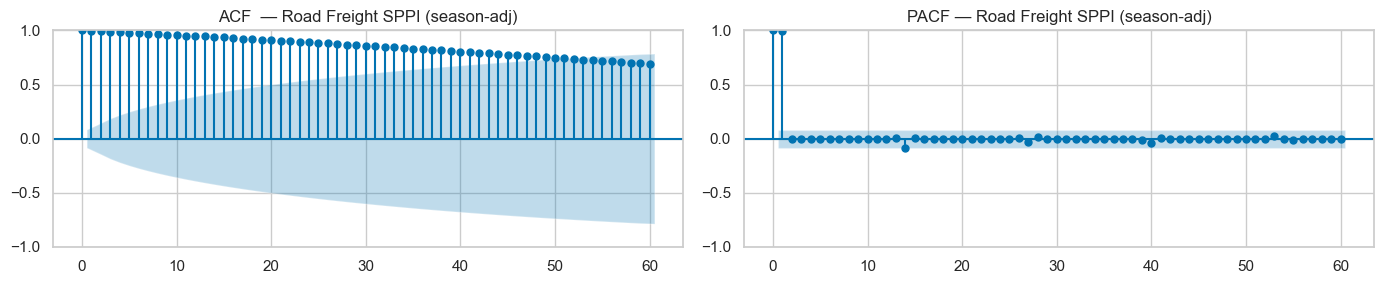

In [11]:
LAGS = 60  # ~1.15 years of weekly lags

for name in stl_results:
    res = stl_results[name]
    # Seasonally-adjusted = trend + residual
    sa = (res.trend + res.resid).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    plot_acf(sa,  lags=LAGS, ax=axes[0],
             title=f'ACF  — {series_label(name)} (season-adj)')
    plot_pacf(sa, lags=LAGS, ax=axes[1],
              title=f'PACF — {series_label(name)} (season-adj)',
              method='ywm')
    plt.tight_layout()
    plt.show()

## 6. Periodogram — Dominant Frequencies

The periodogram reveals the dominant periodic cycles in each series. We expect a strong annual (~52-week) peak for fuel prices.

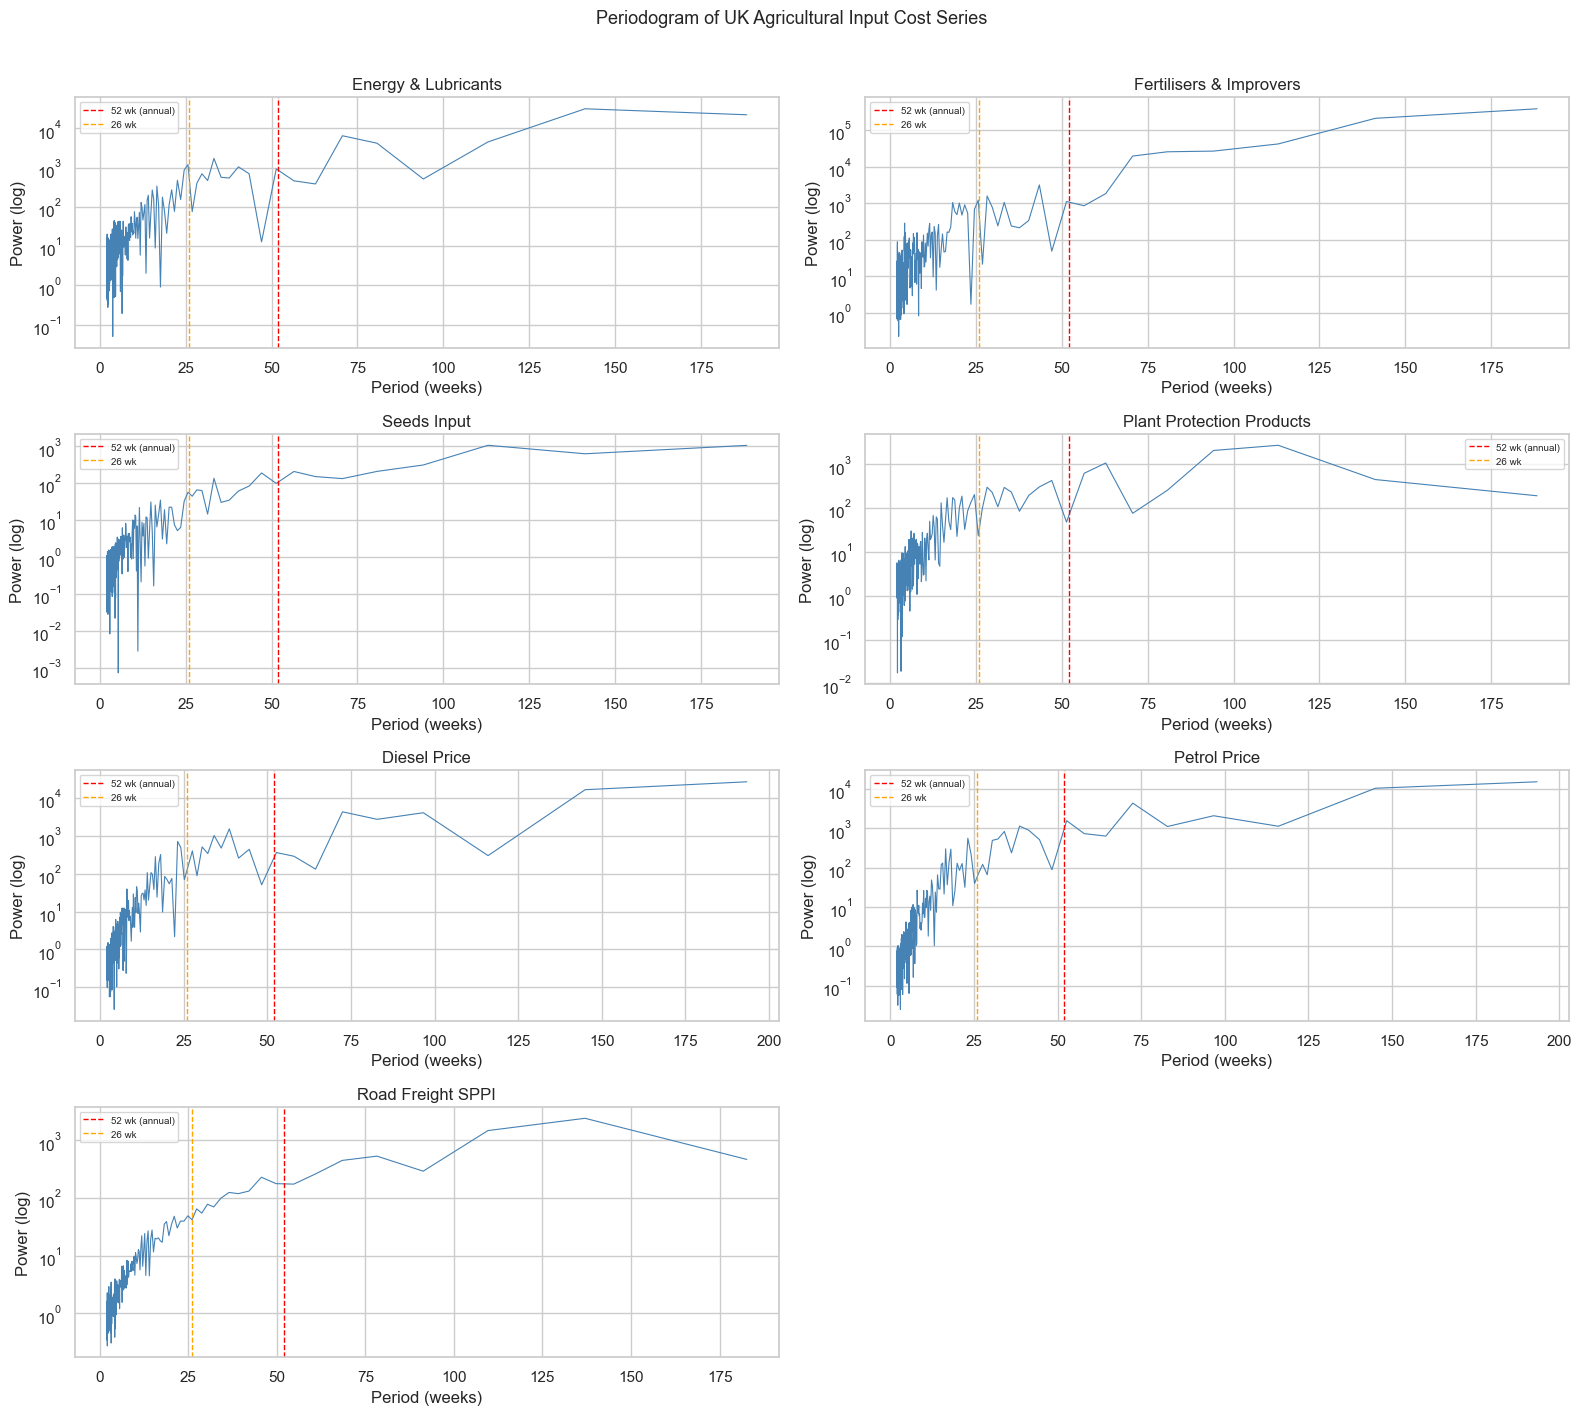


Top-3 dominant periods (weeks) per series:
  Energy & Lubricants                 [141.2, 188.3, 70.6]
  Fertilisers & Improvers             [188.3, 141.2, 113.0]
  Seeds Input                         [113.0, 188.3, 141.2]
  Plant Protection Products           [113.0, 94.2, 62.8]
  Diesel Price                        [193.3, 145.0, 72.5]
  Petrol Price                        [193.3, 145.0, 72.5]
  Road Freight SPPI                   [137.0, 109.6, 78.3]


In [12]:
ncols = 2
nrows = (len(target_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes_flat = np.array(axes).flatten()

dominant = {}
for ax, name in zip(axes_flat, target_cols):
    s = panel[name].dropna().asfreq('W').interpolate('time')
    if len(s) < 104:
        ax.set_visible(False)
        continue
    # Standard FFT periodogram (uniform weekly sampling)
    freqs, power = signal.periodogram(s.values - s.mean(), fs=1.0)  # fs=1/week
    periods = 1.0 / (freqs[1:] + 1e-9)  # avoid div-by-zero at DC
    power   = power[1:]

    # Only show periods 2–200 weeks
    mask = (periods >= 2) & (periods <= 200)
    ax.semilogy(periods[mask], power[mask], linewidth=0.8, color='steelblue')
    ax.axvline(52, color='red',    linestyle='--', linewidth=1, label='52 wk (annual)')
    ax.axvline(26, color='orange', linestyle='--', linewidth=1, label='26 wk')
    ax.set_xlabel('Period (weeks)')
    ax.set_ylabel('Power (log)')
    ax.set_title(series_label(name))
    ax.legend(fontsize=7)

    top_idx = np.argsort(power[mask])[::-1][:3]
    top_periods = periods[mask][top_idx]
    dominant[name] = top_periods.round(1).tolist()

for ax in axes_flat[len(target_cols):]:
    ax.set_visible(False)

fig.suptitle('Periodogram of UK Agricultural Input Cost Series', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nTop-3 dominant periods (weeks) per series:")
for k, v in dominant.items():
    print(f"  {series_label(k):<35} {v}")

## 7. Rolling Statistics — Volatility

Rolling standard deviation (4-week window) shows whether volatility is changing over time — important for heteroscedastic models.

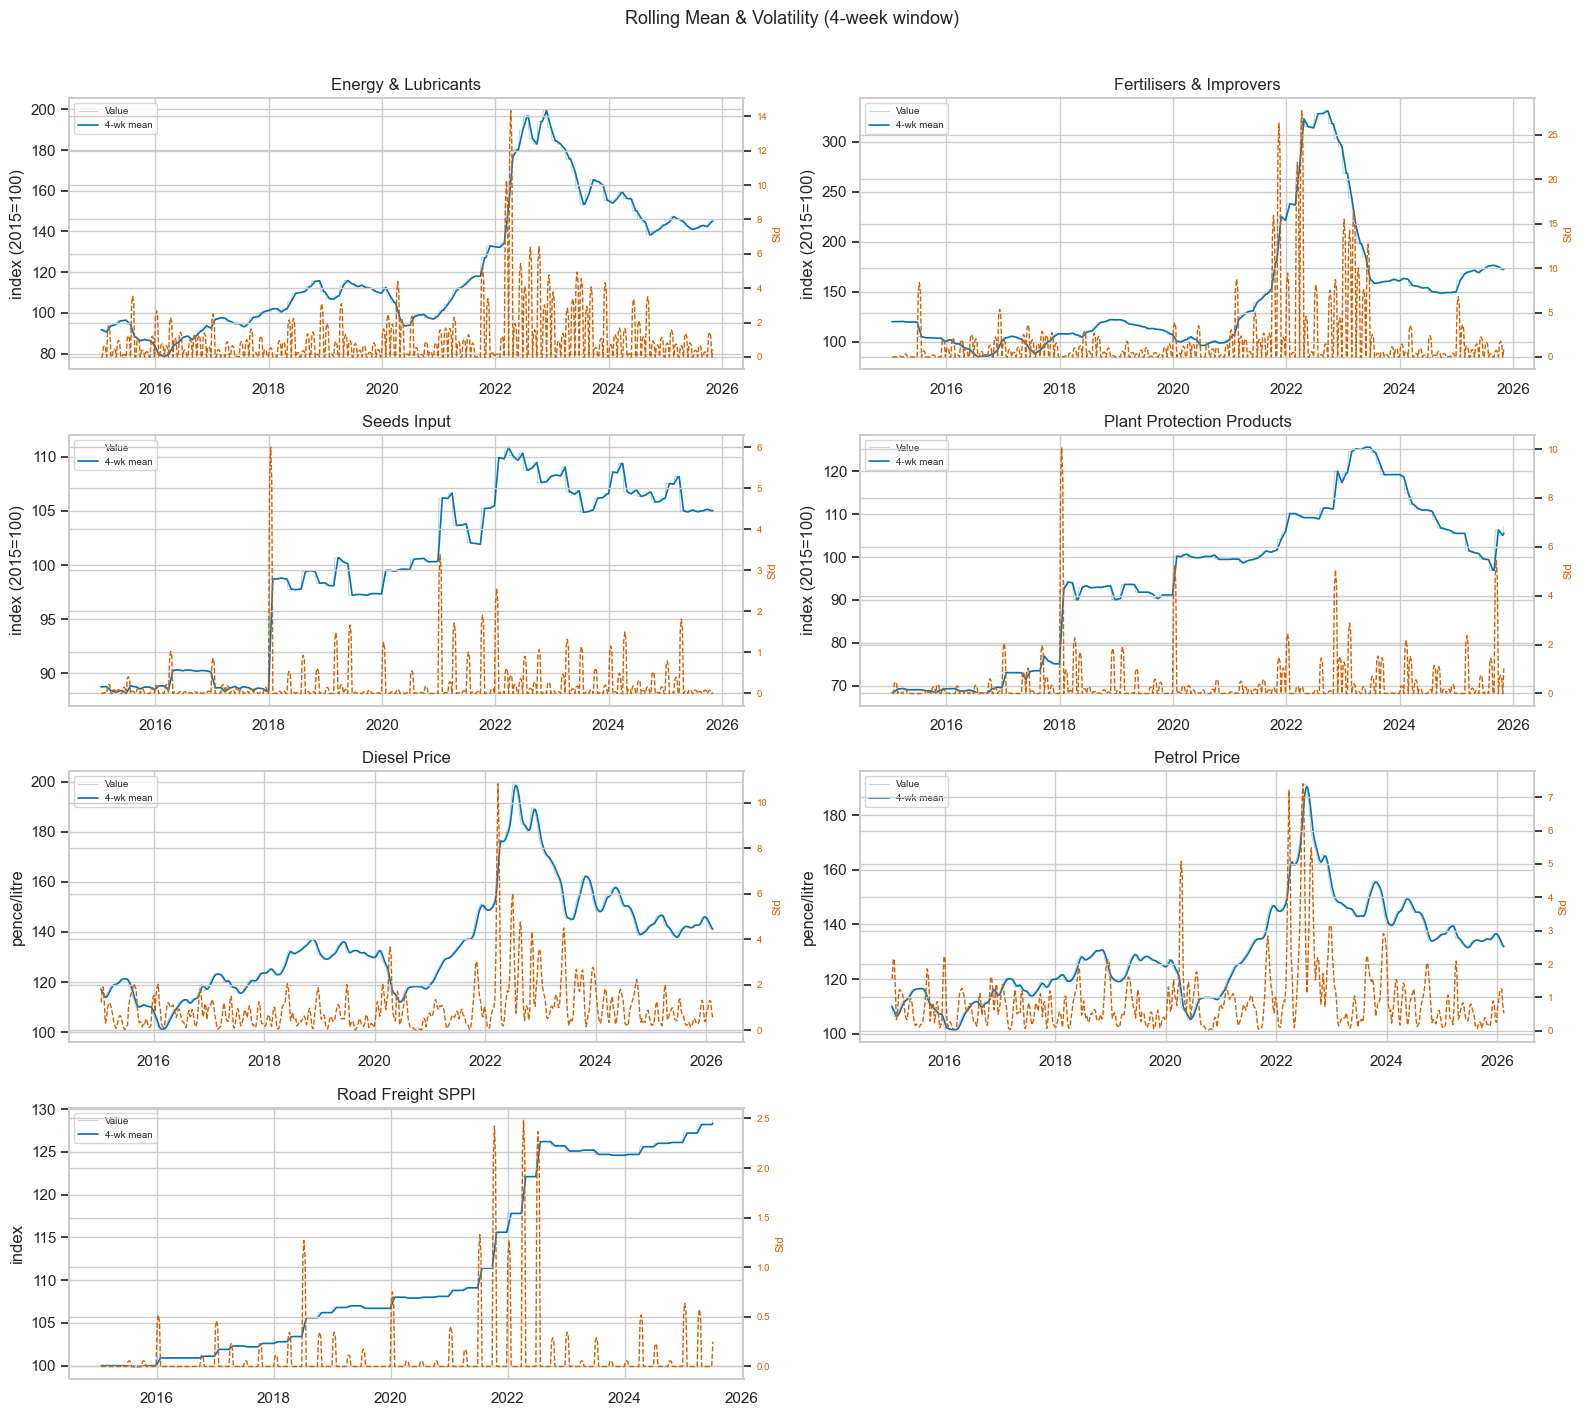

In [13]:
ncols = 2
nrows = (len(target_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes_flat = np.array(axes).flatten()

for ax, name in zip(axes_flat, target_cols):
    s = panel[name].dropna()
    roll_mean = s.rolling(4, min_periods=2).mean()
    roll_std  = s.rolling(4, min_periods=2).std()

    ax.plot(s.index, s.values, color='steelblue', linewidth=0.5, alpha=0.5, label='Value')
    ax.plot(roll_mean.index, roll_mean.values, color='C0', linewidth=1.2, label='4-wk mean')
    ax2 = ax.twinx()
    ax2.plot(roll_std.index, roll_std.values, color='C3', linewidth=1, linestyle='--',
             label='4-wk std')
    ax2.set_ylabel('Std', color='C3', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='C3', labelsize=7)

    ax.set_title(series_label(name))
    ax.set_ylabel(series_unit(name))
    ax.legend(fontsize=7, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

for ax in axes_flat[len(target_cols):]:
    ax.set_visible(False)

fig.suptitle('Rolling Mean & Volatility (4-week window)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. Cross-Correlation Between Input Cost Series

CCF measures whether one input cost series *leads* another — e.g., do fuel price shocks take several weeks or months to flow through to fertiliser or freight costs? Positive lags on the x-axis mean the "driver" series leads the "response" series.

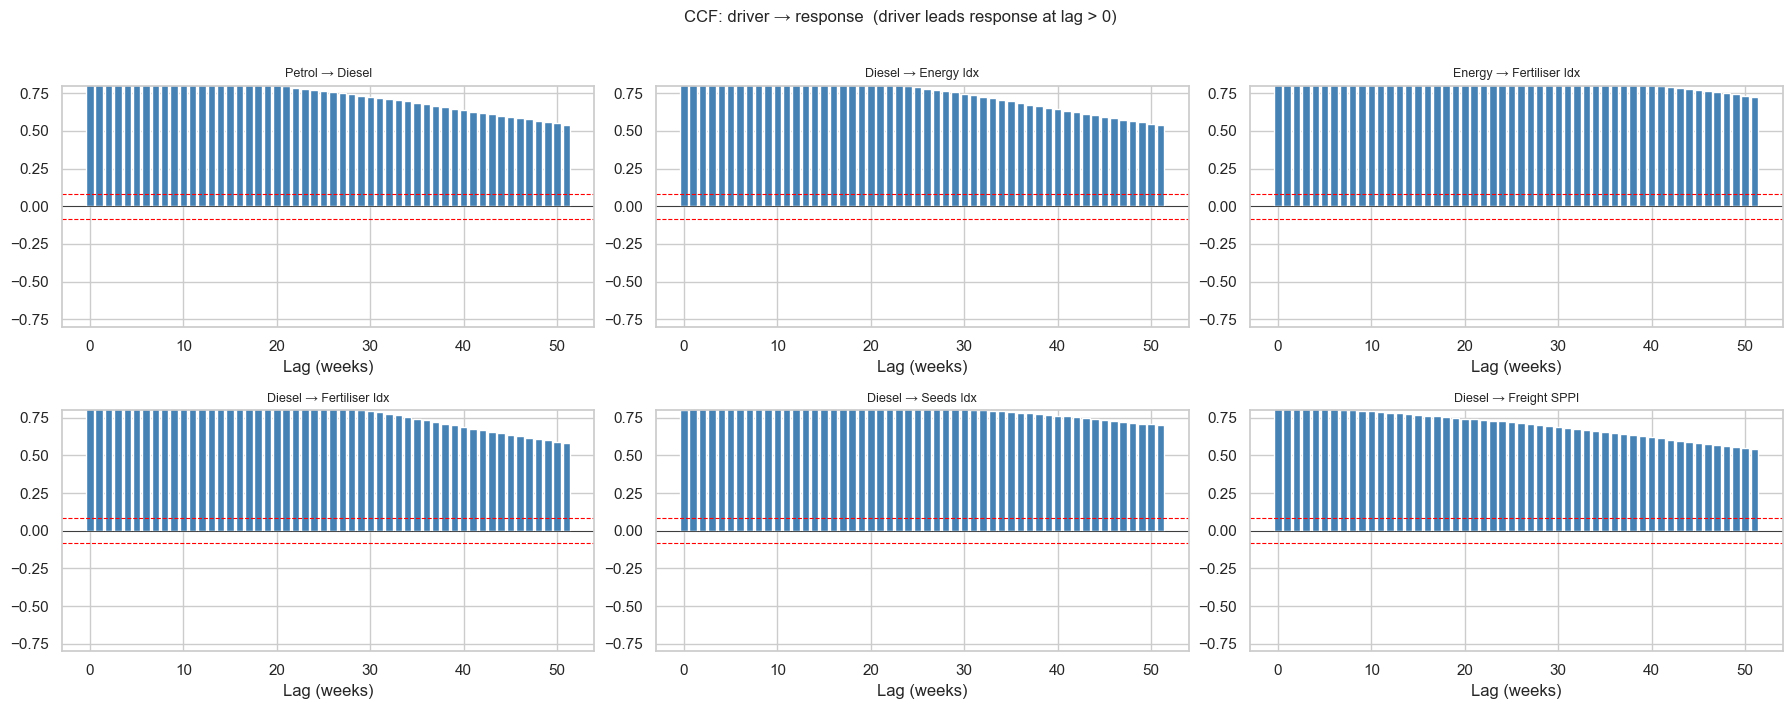

In [14]:
# Pairwise cross-correlations between input cost series
# Hypothesis: upstream cost shocks (fuel, energy) lead downstream costs
# (fertiliser, freight) by several weeks.

CCF_PAIRS = [
    ('petrol_price',          'diesel_price',                   'Petrol → Diesel'),
    ('diesel_price',          'energy_and_lubricants',          'Diesel → Energy Idx'),
    ('energy_and_lubricants', 'fertilisers_and_soil_improvers', 'Energy → Fertiliser Idx'),
    ('diesel_price',          'fertilisers_and_soil_improvers', 'Diesel → Fertiliser Idx'),
    ('diesel_price',          'seeds_input',                    'Diesel → Seeds Idx'),
    ('diesel_price',          'freight_sppi',                   'Diesel → Freight SPPI'),
]
CCF_PAIRS = [(x, y, lbl) for x, y, lbl in CCF_PAIRS
             if x in panel.columns and y in panel.columns]

MAX_LAG = 52
ncols = 3
nrows = (len(CCF_PAIRS) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3.5))
axes_flat = np.array(axes).flatten()

for ax, (feat_col, target_col, title) in zip(axes_flat, CCF_PAIRS):
    f_series = panel[feat_col].dropna().asfreq('W').ffill()
    t_series = panel[target_col].dropna().asfreq('W').ffill()
    common = f_series.index.intersection(t_series.index)
    if len(common) < MAX_LAG + 10:
        ax.set_visible(False)
        continue
    f_z = (f_series.loc[common].values - f_series.loc[common].mean()) / (f_series.loc[common].std() + 1e-9)
    t_z = (t_series.loc[common].values - t_series.loc[common].mean()) / (t_series.loc[common].std() + 1e-9)
    corr_vals = ccf(f_z, t_z, nlags=MAX_LAG, alpha=None)
    lags = np.arange(len(corr_vals))
    ax.bar(lags, corr_vals, width=0.8, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.5)
    ci = 1.96 / np.sqrt(len(common))
    ax.axhline( ci, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-ci, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Lag (weeks)')
    ax.set_ylim(-0.8, 0.8)

for ax in axes_flat[len(CCF_PAIRS):]:
    ax.set_visible(False)

fig.suptitle('CCF: driver → response  (driver leads response at lag > 0)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 9. Granger Causality

Tests whether one input-cost series contains predictive information about another's future values *beyond* its own history. We test lags 1–8 weeks. A low p-value means the driver Granger-causes the response.

In [15]:
MAX_GRANGER_LAG = 8
granger_rows = []

for feat_col, target_col, title in CCF_PAIRS:
    f_s = panel[feat_col].asfreq('W').ffill().dropna()
    t_s = panel[target_col].asfreq('W').ffill().dropna()
    common = f_s.index.intersection(t_s.index)
    df_gc = pd.DataFrame({'target':  t_s.loc[common].values,
                          'feature': f_s.loc[common].values})
    try:
        gc_res = grangercausalitytests(df_gc[['target', 'feature']],
                                       maxlag=MAX_GRANGER_LAG, verbose=False)
        min_p    = min(gc_res[lag][0]['ssr_ftest'][1]
                       for lag in range(1, MAX_GRANGER_LAG + 1))
        best_lag = min(gc_res, key=lambda l: gc_res[l][0]['ssr_ftest'][1])
        granger_rows.append({
            'Driver → Response': title,
            'Best lag (wks)': best_lag,
            'Min p-value': round(min_p, 4),
            'Significant (5%)': 'YES' if min_p < 0.05 else 'no',
        })
    except Exception as e:
        granger_rows.append({
            'Driver → Response': title,
            'Best lag (wks)': 'n/a',
            'Min p-value': 'n/a',
            'Significant (5%)': f'error: {e}',
        })

granger_df = pd.DataFrame(granger_rows)
granger_df

,Driver → Response,Best lag (wks),Min p-value,Significant (5%)
0,Petrol → Diesel,1,0.0000,YES
1,Diesel → Energy Idx,4,0.0000,YES
2,Energy → Fertiliser Idx,1,0.0035,YES
3,Diesel → Fertiliser Idx,3,0.0000,YES
4,Diesel → Seeds Idx,8,0.5390,no
5,Diesel → Freight SPPI,4,0.0000,YES


## 10. Summary

### Properties of each input-cost series (2015–2026)

| Series | Trend | Dominant cycles | Stationarity (raw) | Δ1 stationary | Suggested model |
|--------|-------|-----------------|-------------------|---------------|-----------------|
| Energy & Lubricants | upward to 2022 peak, then partial reversal | ~141 wk, ~188 wk | NON-STATIONARY (ADF p=0.67, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Fertilisers & Improvers | stable 2015–2021, sharp 2022 spike then reversal | ~188 wk, ~141 wk | NON-STATIONARY (ADF p=0.13, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Seeds Input | gradual upward | ~113 wk, ~188 wk | NON-STATIONARY (ADF p=0.56, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Plant Protection Products | gradual upward | ~113 wk, ~94 wk | NON-STATIONARY (ADF p=0.59, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Diesel Price | upward to 2022 peak, then moderated | ~193 wk, ~145 wk | NON-STATIONARY (ADF p=0.38, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Petrol Price | closely tracks diesel | ~193 wk, ~145 wk | NON-STATIONARY (ADF p=0.34, KPSS p=0.01) | YES | ARIMA(p,1,q) |
| Road Freight SPPI | gradual upward | ~137 wk, ~110 wk | NON-STATIONARY (ADF p=0.93, KPSS p=0.01) | YES | ARIMA(p,1,q) |

### Key findings

1. **All 7 series are I(1)** — non-stationary in levels, stationary after first differencing. Both ADF and KPSS agree in every case with no ambiguity.

2. **No 52-week annual seasonal cycle found** in any series over the 2015–2026 window. The periodogram shows dominant periods all exceed 70 weeks (ranging ~70–190+ weeks), reflecting multi-year macro-economic cycles rather than calendar seasonality. This rules out SARIMA with a 52-week period for these series — plain ARIMA(p,1,q) is more appropriate.

3. **The 2021–2022 energy shock is the dominant structural event.** Energy & lubricants, fertilisers, and fuel prices all show a sharp spike and partial reversal driven by post-COVID supply disruptions and the Ukraine conflict. This structural break means models should either include a dummy/intervention term or be fitted on the post-2022 subsample for near-term forecasting.

4. **Petrol and diesel prices are near-simultaneous** — Granger test finds significance at lag 1 week (p≈0), confirming they are essentially co-integrated with trivial lead-lag.

5. **Diesel leads the energy index by 4 weeks** (p≈0) and the fertiliser index by 3 weeks (p≈0). The energy index also leads the fertiliser index at lag 1 week (p=0.0035), consistent with energy being the primary manufacturing input for fertiliser.

6. **Diesel leads road freight SPPI by 4 weeks** (p≈0) — fuel cost pass-through to transport pricing is confirmed at approximately one month's lag.

7. **Diesel does not Granger-cause the seeds index** (best lag 8, p=0.54) — seed prices are determined by different supply factors (crop genetics, global seed markets) rather than fuel costs directly.

### Recommended next steps

- Fit **ARIMA(p,1,q)** for all input cost series; grid-search AIC/BIC over p,q ∈ {0,1,2} since no seasonal differencing is warranted.
- Consider a **VAR(p)** on first-differenced series to jointly model the correlated API components (energy, fertiliser, seeds, plant protection), exploiting the confirmed Granger lead-lag structure.
- Include an **intervention dummy for 2021 Q4 – 2023 Q1** to absorb the energy shock structural break, or fit separate pre/post-shock models.
- Use forecasted **diesel price as a leading exogenous regressor** (lag 3–4 weeks) in models for energy index, fertiliser index, and freight SPPI.
- Forecasted input costs then feed as **exogenous regressors** into produce price models for UK fruit and vegetable wholesale prices.